In [124]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib  # To load the trained model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [126]:
# Load your CSV dataset
test_dataset = pd.read_csv('/content/drive/MyDrive/Predictive Maintenance /predictive_maintenance.csv')  # Replace with your test dataset file path


In [127]:
test_dataset

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure


In [128]:
# Because column UDI and Product ID isn't necessary for prediction, then drop it
test_dataset = test_dataset.drop(columns=['UDI', 'Product ID', 'Target'])
test_dataset.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type
0,M,298.1,308.6,1551,42.8,0,No Failure
1,L,298.2,308.7,1408,46.3,3,No Failure
2,L,298.1,308.5,1498,49.4,5,No Failure
3,L,298.2,308.6,1433,39.5,7,No Failure
4,L,298.2,308.7,1408,40.0,9,No Failure


In [129]:
pd.set_option('future.no_silent_downcasting', True)
test_dataset['Type'] = test_dataset['Type'].replace(to_replace=[i for i in test_dataset['Type'].unique()],
                                value=[i for i in range(3)], inplace=False).astype(int)

In [130]:
test_dataset['Failure Type'] = test_dataset['Failure Type'].replace(to_replace=[i for i in test_dataset['Failure Type'].unique()],
                                value=[i for i in range(6)], inplace=False).astype(int)

In [131]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Failure Type             10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 547.0 KB


In [132]:
test_dataset['Failure Type'].value_counts()

,count
Failure Type,
0,9652
5,112
1,95
3,78
2,45
4,18


In [133]:
X_test = test_dataset.drop('Failure Type', axis=1)  # Features (exclude the target column)
y_actual = test_dataset['Failure Type']  # Actual output (target variable)

In [134]:
from imblearn.over_sampling import SMOTE

X = test_dataset.drop('Failure Type', axis=1)
y = test_dataset['Failure Type']

# Apply random oversampling
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine X_resampled and y_resampled back into a DataFrame if needed
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

In [135]:
# Class distribution
df_resampled['Failure Type'].value_counts()

,count
Failure Type,
0,9652
1,9652
2,9652
3,9652
4,9652
5,9652


In [136]:
test_dataset['temp_diff'] = test_dataset['Process temperature [K]'] - test_dataset['Air temperature [K]']
test_dataset['temp_ratio'] = test_dataset['Process temperature [K]'] / test_dataset['Air temperature [K]']

In [137]:
test_dataset['rpm_diff'] = test_dataset['Torque [Nm]'] - test_dataset['Rotational speed [rpm]']
test_dataset['rpm_ratio'] = test_dataset['Torque [Nm]'] / test_dataset['Rotational speed [rpm]']

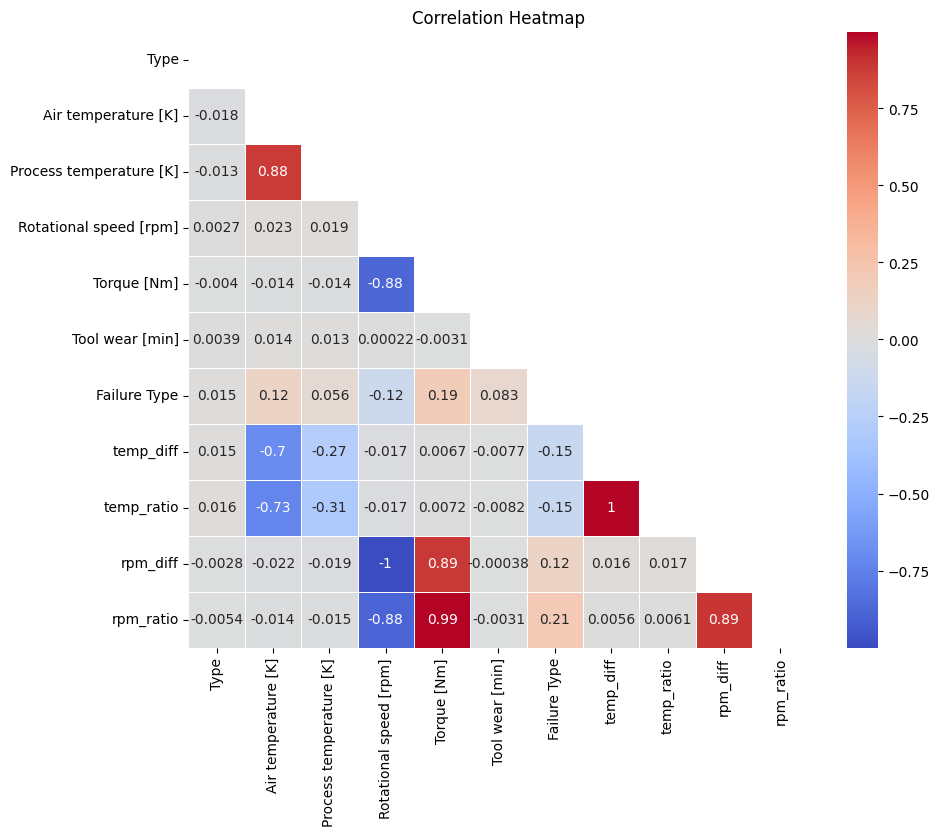

In [138]:
# Calculate the correlation matrix
corr_matrix = test_dataset.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create a heatmap
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [139]:
test_dataset

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type,temp_diff,temp_ratio,rpm_diff,rpm_ratio
0,0,298.1,308.6,1551,42.8,0,0,10.5,1.035223,-1508.2,0.027595
1,1,298.2,308.7,1408,46.3,3,0,10.5,1.035211,-1361.7,0.032884
2,1,298.1,308.5,1498,49.4,5,0,10.4,1.034888,-1448.6,0.032977
3,1,298.2,308.6,1433,39.5,7,0,10.4,1.034876,-1393.5,0.027565
4,1,298.2,308.7,1408,40.0,9,0,10.5,1.035211,-1368.0,0.028409
...,...,...,...,...,...,...,...,...,...,...,...
9995,0,298.8,308.4,1604,29.5,14,0,9.6,1.032129,-1574.5,0.018392
9996,2,298.9,308.4,1632,31.8,17,0,9.5,1.031783,-1600.2,0.019485
9997,0,299.0,308.6,1645,33.4,22,0,9.6,1.032107,-1611.6,0.020304
9998,2,299.0,308.7,1408,48.5,25,0,9.7,1.032441,-1359.5,0.034446


In [140]:
# Load the trained model
loaded_model = joblib.load('/content/drive/MyDrive/FInal Model /predictive_analysis_model.pkl')

In [141]:
!pip install catboost

In [142]:
# Renaming columns in the test dataset to match the expected feature names
test_dataset.rename(columns={
    'Air temperature [K]': 'Air_temperature__K_',
    'Process temperature [K]': 'Process_temperature__K_',
    'Rotational speed [rpm]': 'Rotational_speed__rpm_',
    'Torque [Nm]': 'Torque__Nm_',
    'Tool wear [min]': 'Tool_wear__min_',
    'Failure Type': 'Failure_Type',
}, inplace=True)


In [143]:
# Print column names to identify other mismatches
print(test_dataset.columns)


Index(['Type', 'Air_temperature__K_', 'Process_temperature__K_',
       'Rotational_speed__rpm_', 'Torque__Nm_', 'Tool_wear__min_',
       'Failure_Type', 'temp_diff', 'temp_ratio', 'rpm_diff', 'rpm_ratio'],
      dtype='object')


In [144]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air_temperature__K_      10000 non-null  float64
 2   Process_temperature__K_  10000 non-null  float64
 3   Rotational_speed__rpm_   10000 non-null  int64  
 4   Torque__Nm_              10000 non-null  float64
 5   Tool_wear__min_          10000 non-null  int64  
 6   Failure_Type             10000 non-null  int64  
 7   temp_diff                10000 non-null  float64
 8   temp_ratio               10000 non-null  float64
 9   rpm_diff                 10000 non-null  float64
 10  rpm_ratio                10000 non-null  float64
dtypes: float64(7), int64(4)
memory usage: 859.5 KB


In [145]:
# Make predictions
predictions = loaded_model.predict(test_dataset)

In [146]:
# Add predictions to the dataset
test_dataset['Predictions'] = predictions

In [147]:
# For comparing, let's assume 'Actual_Failure_Type' exists in the dataset
# Create a new column for actual/predicted comparison
test_dataset['Actual_Predicted'] = test_dataset['Failure_Type'].astype(str) + '/' + test_dataset['Predictions'].astype(str)

# # Display the first few rows with actual vs predicted comparison
# print("\nComparison of Actual vs Predicted Failure Types:")
# print(test_dataset[['Failure_Type', 'Predictions', 'Actual_Predicted']].head())

# If you want to display the failure type comparison counts:
failure_counts = test_dataset.groupby(['Failure_Type', 'Predictions']).size().reset_index(name='Count')

# # Display the failure counts
# print("\nFailure Counts (Actual vs Predicted):")
# print(failure_counts)

# Optionally, you can map numeric failure types to human-readable strings
failure_type_mapping = {
    0: 'No Failure',
    1: 'Heat Dissipation Failure',
    2: 'Power Failure',
    3: 'Overstrain Failure',
    4: 'Tool Wear Failure',
    5: 'Random Failures'
}

# Map the failure types to their labels
test_dataset['Actual_Failure_Type_Label'] = test_dataset['Failure_Type'].map(failure_type_mapping)
test_dataset['Predictions_Label'] = test_dataset['Predictions'].map(failure_type_mapping)

# Display the comparison with labels
print("\nComparison with Labels (Actual vs Predicted):")
print(test_dataset[['Actual_Failure_Type_Label', 'Predictions_Label']].head())
print(test_dataset[['Actual_Failure_Type_Label', 'Predictions_Label']].tail())

# # Display the failure counts
# print("\nFailure Counts (Actual vs Predicted):")
# print(failure_counts)

# Evaluate model performance (if actual outputs are available)
accuracy = accuracy_score(y_actual, predictions)
precision = precision_score(y_actual, predictions, average='weighted')
recall = recall_score(y_actual, predictions, average='weighted')
f1 = f1_score(y_actual, predictions, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")



Comparison with Labels (Actual vs Predicted):
  Actual_Failure_Type_Label Predictions_Label
0                No Failure        No Failure
1                No Failure        No Failure
2                No Failure        No Failure
3                No Failure        No Failure
4                No Failure        No Failure
     Actual_Failure_Type_Label Predictions_Label
9995                No Failure        No Failure
9996                No Failure        No Failure
9997                No Failure        No Failure
9998                No Failure        No Failure
9999                No Failure        No Failure
Accuracy: 0.9728
Precision: 0.9903
Recall: 0.9728
F1 Score: 0.9797


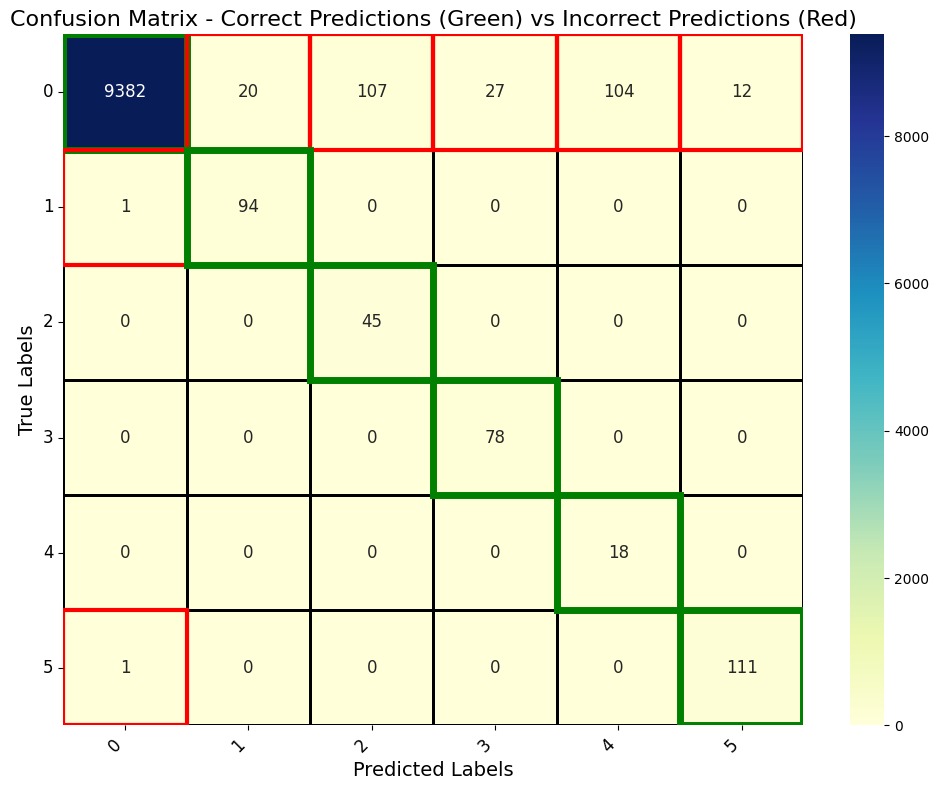

In [148]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'test_dataset' already has the actual and predicted values
# Replace 'Failure_Type' with the true labels column and 'Predictions' with predictions column in your dataset
y_true = test_dataset['Failure_Type']  # Actual labels
y_pred = test_dataset['Predictions']  # Predicted labels

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize the confusion matrix for better color scaling (optional)
# cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create a figure for the plot
plt.figure(figsize=(10, 8))

# Plot the heatmap without direct colors (we will customize them manually)
ax = sns.heatmap(cm, annot=True, fmt='g', cmap="YlGnBu", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true),
                 cbar=True, linewidths=1, linecolor='black', annot_kws={"size": 12})

# Loop through the matrix to apply custom colors to each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Diagonal elements (correct predictions) are green
        if i == j:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='green', lw=5))
        # Off-diagonal elements (incorrect predictions) are red
        elif cm[i, j] > 0:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=3))

# Add labels, title, and custom tickmarks
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.title('Confusion Matrix - Correct Predictions (Green) vs Incorrect Predictions (Red)', fontsize=16)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Adjust layout for better presentation
plt.tight_layout()
plt.show()
